# Baseline RUL Modeling

This notebook builds the first machine-learning baselines for predicting
Remaining Useful Life (RUL) on the NASA C-MAPSS FD001 dataset.

The main goals are to:

- prepare a leakage-safe modeling dataset,
- split the data by engine rather than by individual rows,
- establish simple reference models,
- and create a trustworthy baseline before introducing more complex
  algorithms or extensive tuning.

This notebook begins with dataset preparation and validation. Model
training is introduced only after confirming that the train and
validation sets contain completely separate engines.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import (
    ROLLING_WINDOW,
    EMA_SPAN,
    RUL_CAP,
)
from src.data_loader import load_cmapss_data
from src.preprocessing import add_sensor_history_features
from src.rul_builder import add_train_rul

## Load and Prepare the Training Data

The FD001 training dataset contains complete run-to-failure histories
for 100 engines.

The dataset is loaded through the shared project data loader, and the
RUL target is created using the centralized RUL builder.

The final project target uses capped RUL:

$$
RUL_{capped} = \min(RUL_{linear}, 125)
$$

The cap was selected after the controlled target-ablation study in
Notebook 06.

The final engine lifetime is used internally only for target
construction and is not retained as a model input.

In [2]:
train_path = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "train_FD001.txt"
)

df = load_cmapss_data(train_path)

df = add_train_rul(
    df,
    rul_cap=RUL_CAP,
)

print(df["RUL"].min())
print(df["RUL"].max())
print(df["RUL"].describe())

df.head()

0
125
count    20631.000000
mean        86.829286
std         41.673699
min          0.000000
25%         51.000000
50%        103.000000
75%        125.000000
max        125.000000
Name: RUL, dtype: float64


,id,cycle,setting_1,setting_2,setting_3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,125
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,125
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,125
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,125
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,125


In [3]:
assert df.shape[0] == 20631
assert df["id"].nunique() == 100
assert "RUL" in df.columns
assert "max_cycle" not in df.columns

assert df["RUL"].min() == 0, (
    "RUL must reach zero at the final cycle."
)

assert df["RUL"].max() == RUL_CAP, (
    "The capped RUL target must reach the configured maximum."
)

assert (df["RUL"] <= RUL_CAP).all(), (
    "RUL values must not exceed the configured cap."
)

assert (df["RUL"] >= 0).all(), (
    "RUL values must not be negative."
)

assert (df.groupby("id").tail(1)["RUL"] == 0).all(), (
    "The final cycle of every engine must have RUL equal to zero."
)

print("Training dataset prepared successfully.")
print("Rows:", len(df))
print("Engines:", df["id"].nunique())
print("Columns:", df.shape[1])
print("Maximum RUL:", df["RUL"].max())

Training dataset prepared successfully.
Rows: 20631
Engines: 100
Columns: 27
Maximum RUL: 125


## Candidate Sensor Set

The sensor-analysis notebook identified a preliminary set of sensors
that show meaningful variation and relationships with RUL:

- `s2`
- `s3`
- `s4`
- `s7`
- `s11`
- `s12`
- `s15`
- `s17`
- `s20`
- `s21`

This is an initial modeling set rather than a permanently fixed feature
selection decision.

Later experiments may compare this set with alternative sensor
combinations, including sensors excluded during exploratory analysis.

In [4]:
selected_sensors = [
    "s2",
    "s3",
    "s4",
    "s7",
    "s11",
    "s12",
    "s15",
    "s17",
    "s20",
    "s21",
]

assert all(
    sensor in df.columns
    for sensor in selected_sensors
)

print("Selected sensors:", selected_sensors)
print("Number of selected sensors:", len(selected_sensors))

Selected sensors: ['s2', 's3', 's4', 's7', 's11', 's12', 's15', 's17', 's20', 's21']
Number of selected sensors: 10


## Leakage-Safe Historical Features

For every selected sensor, the preprocessing function creates:

- the raw sensor measurement,
- one-cycle difference,
- rolling mean,
- exponential moving average,
- and expanding mean.

All historical features are calculated independently for each engine
and use only the current and previous cycles.

The rolling window and EMA span are both configured as 10 cycles.

This configuration was selected through the controlled temporal-window
ablation in Notebook 06, which compared values of 3, 5, 10, and 20
cycles while keeping the model, target, sensor set, hyperparameters,
and engine-level split fixed.

The 10-cycle configuration achieved the best validation MAE, RMSE, and
R² and is therefore used throughout this notebook.

In [5]:
modeling_df = add_sensor_history_features(
    df,
    sensors=selected_sensors,
    rolling_window=ROLLING_WINDOW,
    ema_span=EMA_SPAN,
).reset_index(drop=True)

print("Original shape:", df.shape)
print("Modeling shape:", modeling_df.shape)

Original shape: (20631, 27)
Modeling shape: (20631, 67)


In [6]:
rolling_feature_count = modeling_df.filter(
    regex=f"rolling_mean_{ROLLING_WINDOW}$"
).shape[1]

ema_feature_count = modeling_df.filter(
    regex=f"ema_{EMA_SPAN}$"
).shape[1]

assert rolling_feature_count == len(selected_sensors), (
    "Unexpected number of rolling-mean features."
)

assert ema_feature_count == len(selected_sensors), (
    "Unexpected number of EMA features."
)

assert modeling_df["RUL"].max() == RUL_CAP

print("Final target and temporal configuration validated.")

Final target and temporal configuration validated.


In [7]:
historical_features = [
    f"{sensor}_{suffix}"
    for sensor in selected_sensors
    for suffix in [
        "diff_1",
        f"rolling_mean_{ROLLING_WINDOW}",
        f"ema_{EMA_SPAN}",
        "expanding_mean",
    ]
]

raw_features = selected_sensors.copy()

feature_columns = (
    ["cycle"]
    + raw_features
    + historical_features
)

target_column = "RUL"
group_column = "id"

print("Raw sensor features:", len(raw_features))
print("Historical features:", len(historical_features))
print("Total model features:", len(feature_columns))

Raw sensor features: 10
Historical features: 40
Total model features: 51


In [8]:
assert len(feature_columns) == 51
assert len(set(feature_columns)) == len(feature_columns)

assert target_column not in feature_columns
assert group_column not in feature_columns
assert "max_cycle" not in feature_columns
assert "cycle_progress" not in feature_columns

assert modeling_df[feature_columns].isna().sum().sum() == 0
assert len(modeling_df) == len(df)

print("Model feature validation passed.")

Model feature validation passed.


## Engine-Level Train–Validation Split

A random row-level split would cause data leakage because cycles from
the same engine could appear in both the training and validation sets.

The model would then be evaluated on later or earlier observations from
engines it had already seen during training, producing unrealistically
optimistic results.

To prevent this, the split is performed using engine IDs as groups.
Every engine belongs entirely to either the training set or the
validation set.

In [9]:
group_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42,
)

train_indices, validation_indices = next(
    group_splitter.split(
        modeling_df,
        groups=modeling_df[group_column],
    )
)

train_df = (
    modeling_df
    .iloc[train_indices]
    .reset_index(drop=True)
)

validation_df = (
    modeling_df
    .iloc[validation_indices]
    .reset_index(drop=True)
)

In [10]:
train_engines = set(train_df["id"].unique())
validation_engines = set(validation_df["id"].unique())

shared_engines = train_engines.intersection(
    validation_engines
)

print("Training rows:", len(train_df))
print("Validation rows:", len(validation_df))
print("Training engines:", len(train_engines))
print("Validation engines:", len(validation_engines))
print("Shared engines:", len(shared_engines))

Training rows: 16561
Validation rows: 4070
Training engines: 80
Validation engines: 20
Shared engines: 0


In [11]:
assert len(shared_engines) == 0, (
    "An engine must not appear in both training and validation sets."
)

assert len(train_engines) == 80
assert len(validation_engines) == 20

assert train_engines.union(
    validation_engines
) == set(modeling_df["id"].unique())

print("Engine-level split validation passed.")

Engine-level split validation passed.


In [12]:
X_train = train_df[feature_columns]
y_train = train_df[target_column]

X_validation = validation_df[feature_columns]
y_validation = validation_df[target_column]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_validation shape:", X_validation.shape)
print("y_validation shape:", y_validation.shape)

print("\nFull dataset RUL range:")
print(df["RUL"].min(), df["RUL"].max())

print("\nTraining target range:")
print(y_train.min(), y_train.max())

print("\nValidation target range:")
print(y_validation.min(), y_validation.max())

print("\nTraining mean:", y_train.mean())
print("Validation mean:", y_validation.mean())

assert y_train.max() == RUL_CAP
assert y_validation.max() == RUL_CAP

print("\nCapped modeling targets validated.")

X_train shape: (16561, 51)
y_train shape: (16561,)
X_validation shape: (4070, 51)
y_validation shape: (4070,)

Full dataset RUL range:
0 125

Training target range:
0 125

Validation target range:
0 125

Training mean: 86.95881891190146
Validation mean: 86.3022113022113

Capped modeling targets validated.


## Modeling Dataset Preparation Summary

The modeling dataset is now ready for baseline training:

- RUL was constructed without retaining future engine lifetime
  information.
- Raw sensor measurements were preserved.
- Leakage-safe historical features were added for the selected sensors.
- The target and engine identifier were excluded from model inputs.
- Training and validation data were separated by engine ID.
- No engine appears in both subsets.

The next step is to establish a naive reference using a dummy regressor
before training real predictive models.

## Naive Baseline Model

Before training a real predictive model, we establish a naive reference
using `DummyRegressor`.

The dummy model ignores all sensor and historical features and predicts
the mean RUL observed in the training set for every validation row.

This baseline answers an important question:

> Does a real model learn useful degradation patterns, or is it no
> better than repeatedly predicting a single average value?

Every meaningful predictive model should outperform this reference.

In [13]:
dummy_model = DummyRegressor(
    strategy="mean"
)

dummy_model.fit(
    X_train,
    y_train,
)

dummy_predictions = dummy_model.predict(
    X_validation
)

In [14]:
print("Training mean RUL:", y_train.mean())
print("First dummy predictions:", dummy_predictions[:5])
print("Unique dummy predictions:", np.unique(dummy_predictions))

Training mean RUL: 86.95881891190146
First dummy predictions: [86.95881891 86.95881891 86.95881891 86.95881891 86.95881891]
Unique dummy predictions: [86.95881891]


In [15]:
assert len(np.unique(dummy_predictions)) == 1, (
    "Mean-strategy DummyRegressor should produce one constant prediction."
)

## Regression Evaluation Metrics

The baseline is evaluated using three complementary metrics:

- **MAE — Mean Absolute Error**  
  The average absolute distance between predicted and true RUL values.
  It is directly interpretable in operating cycles.

- **RMSE — Root Mean Squared Error**  
  Similar to MAE, but it penalizes large errors more strongly.

- **R² — Coefficient of Determination**  
  Measures how much target variation is explained relative to predicting
  the validation-set mean. A score of `1` is ideal, `0` indicates no
  improvement over that reference, and negative values are possible
  when predictions are worse.

In [16]:
dummy_mae = mean_absolute_error(
    y_validation,
    dummy_predictions,
)

dummy_rmse = root_mean_squared_error(
    y_validation,
    dummy_predictions,
)

dummy_r2 = r2_score(
    y_validation,
    dummy_predictions,
)

print(f"Dummy MAE:  {dummy_mae:.3f}")
print(f"Dummy RMSE: {dummy_rmse:.3f}")
print(f"Dummy R²:   {dummy_r2:.3f}")

Dummy MAE:  36.930
Dummy RMSE: 41.721
Dummy R²:   -0.000


In [17]:
baseline_results = pd.DataFrame(
    [
        {
            "model": "Dummy Mean",
            "MAE": dummy_mae,
            "RMSE": dummy_rmse,
            "R2": dummy_r2,
        }
    ]
)

baseline_results

,model,MAE,RMSE,R2
0,Dummy Mean,36.929803,41.720825,-0.000248


In [18]:
manual_dummy_predictions = np.full(
    shape=len(y_validation),
    fill_value=y_train.mean(),
)

np.testing.assert_allclose(
    dummy_predictions,
    manual_dummy_predictions,
)

print("Dummy baseline validation passed.")

Dummy baseline validation passed.


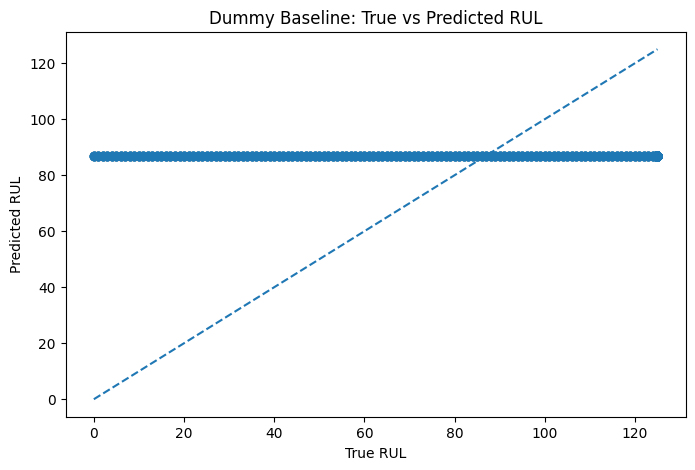

In [19]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_validation,
    dummy_predictions,
    alpha=0.25,
)

minimum_rul = min(
    y_validation.min(),
    dummy_predictions.min(),
)

maximum_rul = max(
    y_validation.max(),
    dummy_predictions.max(),
)

plt.plot(
    [minimum_rul, maximum_rul],
    [minimum_rul, maximum_rul],
    linestyle="--",
)

plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("Dummy Baseline: True vs Predicted RUL")
plt.show()

### Baseline Insight

The dummy model produces the same prediction for every validation
observation because it does not use the sensor features.

Its errors therefore establish a minimum reference level rather than a
useful maintenance model.

The next models must demonstrate that the sensor measurements and
historical features contain predictive information by achieving:

- lower MAE,
- lower RMSE,
- and higher R².

## Ridge Regression Baseline

Ridge Regression is the first model that uses the sensor and historical
features to predict RUL.

It extends ordinary linear regression by adding L2 regularization,
which discourages excessively large coefficients.

This is useful in the current dataset because raw sensor values,
rolling means, EMA features, and expanding means may contain strongly
correlated information.

A `StandardScaler` and the Ridge model are combined inside a
scikit-learn `Pipeline`.

The scaler is fitted only on the training engines and is then applied
to the validation engines. This prevents validation information from
influencing the preprocessing stage.

In [20]:
ridge_model = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "ridge",
            Ridge(alpha=1.0),
        ),
    ]
)

In [21]:
ridge_model.fit(
    X_train,
    y_train,
)

ridge_predictions = ridge_model.predict(
    X_validation
)

In [22]:
print("First Ridge predictions:")
print(ridge_predictions[:5])

print("\nPrediction range:")
print("Minimum:", ridge_predictions.min())
print("Maximum:", ridge_predictions.max())

First Ridge predictions:
[132.49643127 121.59768963 116.59501012 118.88142297 117.72876536]

Prediction range:
Minimum: -54.724606655473636
Maximum: 146.1003952872668


In [23]:
negative_ridge_predictions = (
    ridge_predictions < 0
).sum()

negative_ridge_percentage = (
    negative_ridge_predictions
    / len(ridge_predictions)
    * 100
)

print(
    "Negative Ridge predictions:",
    negative_ridge_predictions,
)

print(
    f"Negative prediction percentage: "
    f"{negative_ridge_percentage:.2f}%"
)

Negative Ridge predictions: 161
Negative prediction percentage: 3.96%


### Physical Plausibility of Ridge Predictions

Ridge Regression is an unconstrained linear model, so it can predict
negative RUL values even though Remaining Useful Life cannot be
negative in practice.

The raw predictions are retained in this baseline to report the model's
unmodified behavior honestly.

A later evaluation stage may compare raw predictions with a
non-negative post-processing rule, but such clipping must be documented
and evaluated rather than applied silently.

In [24]:
assert len(ridge_predictions) == len(y_validation)

assert np.isfinite(ridge_predictions).all(), (
    "Ridge predictions must not contain NaN or infinite values."
)

assert len(np.unique(ridge_predictions)) > 1, (
    "Ridge should not produce one constant prediction."
)

In [25]:
ridge_mae = mean_absolute_error(
    y_validation,
    ridge_predictions,
)

ridge_rmse = root_mean_squared_error(
    y_validation,
    ridge_predictions,
)

ridge_r2 = r2_score(
    y_validation,
    ridge_predictions,
)

print(f"Ridge MAE:  {ridge_mae:.3f}")
print(f"Ridge RMSE: {ridge_rmse:.3f}")
print(f"Ridge R²:   {ridge_r2:.3f}")

Ridge MAE:  12.817
Ridge RMSE: 16.047
Ridge R²:   0.852


In [26]:
ridge_result = pd.DataFrame(
    [
        {
            "model": "Ridge",
            "MAE": ridge_mae,
            "RMSE": ridge_rmse,
            "R2": ridge_r2,
        }
    ]
)

baseline_results = pd.concat(
    [
        baseline_results,
        ridge_result,
    ],
    ignore_index=True,
)

baseline_results

,model,MAE,RMSE,R2
0,Dummy Mean,36.929803,41.720825,-0.000248
1,Ridge,12.817189,16.047358,0.852018


In [27]:
assert ridge_mae < dummy_mae, (
    "Ridge did not improve MAE over the dummy baseline."
)

assert ridge_rmse < dummy_rmse, (
    "Ridge did not improve RMSE over the dummy baseline."
)

assert ridge_r2 > dummy_r2, (
    "Ridge did not improve R² over the dummy baseline."
)

print("Ridge outperformed the dummy baseline.")

Ridge outperformed the dummy baseline.


In [28]:
ridge_mae_improvement = (
    (dummy_mae - ridge_mae)
    / dummy_mae
    * 100
)

ridge_rmse_improvement = (
    (dummy_rmse - ridge_rmse)
    / dummy_rmse
    * 100
)

print(
    f"MAE improvement over Dummy: "
    f"{ridge_mae_improvement:.2f}%"
)

print(
    f"RMSE improvement over Dummy: "
    f"{ridge_rmse_improvement:.2f}%"
)

MAE improvement over Dummy: 65.29%
RMSE improvement over Dummy: 61.54%


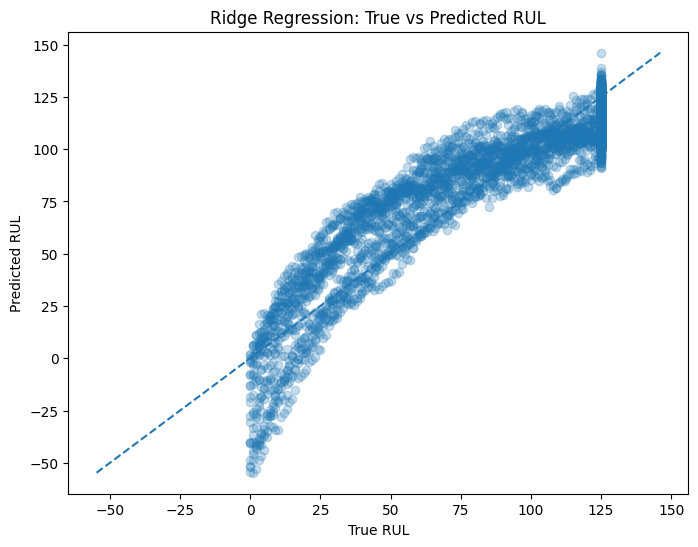

In [29]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_validation,
    ridge_predictions,
    alpha=0.25,
)

minimum_value = min(
    y_validation.min(),
    ridge_predictions.min(),
)

maximum_value = max(
    y_validation.max(),
    ridge_predictions.max(),
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
)

plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("Ridge Regression: True vs Predicted RUL")
plt.show()

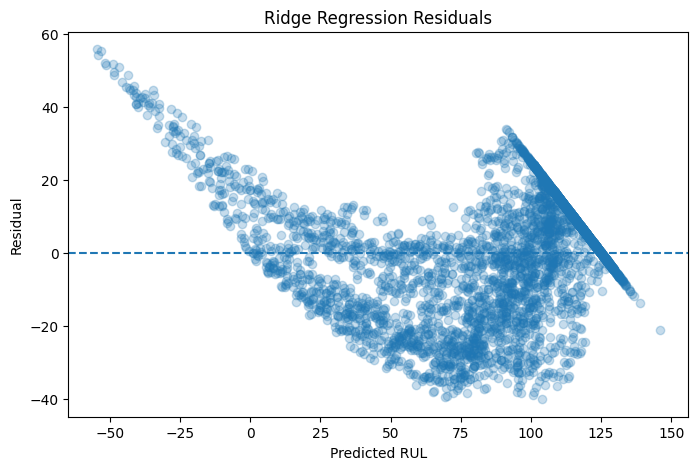

In [30]:
ridge_residuals = (
    y_validation.to_numpy()
    - ridge_predictions
)

plt.figure(figsize=(8, 5))

plt.scatter(
    ridge_predictions,
    ridge_residuals,
    alpha=0.25,
)

plt.axhline(
    y=0,
    linestyle="--",
)

plt.xlabel("Predicted RUL")
plt.ylabel("Residual")
plt.title("Ridge Regression Residuals")
plt.show()

### Ridge Residual Interpretation

Residuals represent:

`true RUL - predicted RUL`

- A positive residual means the model underestimated RUL.
- A negative residual means the model overestimated RUL.
- Residuals close to zero indicate more accurate predictions.

A useful model should produce residuals distributed around zero without
a strong systematic pattern.

Visible curves, widening spreads, or structured patterns would suggest
that a linear model cannot fully capture the degradation relationship.

In [31]:
ridge_estimator = ridge_model.named_steps["ridge"]

ridge_coefficients = pd.Series(
    ridge_estimator.coef_,
    index=feature_columns,
).sort_values(
    key=np.abs,
    ascending=False,
)

ridge_coefficients.head(15)

s12_expanding_mean    -11.701314
s20_expanding_mean     -8.389823
s15_rolling_mean_10    -5.599084
s20_rolling_mean_10     5.268594
s17_ema_10             -4.507984
s11_rolling_mean_10    -4.112933
s20_ema_10              3.938422
s2_rolling_mean_10     -3.257473
s12_rolling_mean_10     3.000892
s4_rolling_mean_10     -2.999385
s17_expanding_mean      2.989786
s21_rolling_mean_10     2.916395
s7_rolling_mean_10      2.863258
s12_ema_10             -2.760405
s11_expanding_mean      2.488515
dtype: float64

### Coefficient Note

Because the input features were standardized, Ridge coefficients can be
compared on a more consistent scale.

However, coefficient magnitude should not be interpreted as causal
importance. Correlated features may distribute predictive influence
across several related columns.

### Ridge Baseline Insight

Ridge Regression provides the first evidence of whether the selected
sensor measurements and historical features contain predictive
information beyond a constant average prediction.

If Ridge substantially improves MAE, RMSE, and R² over the dummy
baseline, then the current feature set captures useful degradation
patterns.

Remaining structured residuals would also justify testing a nonlinear
model next.

## Random Forest Regression

Random Forest is the first nonlinear model in this project.

It combines many decision trees and averages their predictions.
Each tree learns different threshold-based relationships between the
sensor features and RUL.

Unlike Ridge Regression, Random Forest does not assume that the
relationship between the inputs and RUL is linear.

This makes it useful for detecting:

- nonlinear degradation patterns,
- interactions between sensors,
- threshold effects,
- and different behavior across operating regions.

The model does not require feature scaling, so the raw and historical
features can be used directly.

In [32]:
random_forest_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
)

In [33]:
random_forest_model.fit(
    X_train,
    y_train,
)

random_forest_predictions = random_forest_model.predict(
    X_validation
)

In [34]:
print("First Random Forest predictions:")
print(random_forest_predictions[:5])

print("\nPrediction range:")
print("Minimum:", random_forest_predictions.min())
print("Maximum:", random_forest_predictions.max())

First Random Forest predictions:
[119.20415476 119.53022619 119.64133929 121.53684524 121.4672381 ]

Prediction range:
Minimum: 0.961119047619048
Maximum: 125.0


In [35]:
assert len(random_forest_predictions) == len(y_validation)

assert np.isfinite(random_forest_predictions).all(), (
    "Random Forest predictions must not contain NaN or infinite values."
)

assert len(np.unique(random_forest_predictions)) > 1, (
    "Random Forest should not produce constant predictions."
)

In [36]:
random_forest_mae = mean_absolute_error(
    y_validation,
    random_forest_predictions,
)

random_forest_rmse = root_mean_squared_error(
    y_validation,
    random_forest_predictions,
)

random_forest_r2 = r2_score(
    y_validation,
    random_forest_predictions,
)

print(f"Random Forest MAE:  {random_forest_mae:.3f}")
print(f"Random Forest RMSE: {random_forest_rmse:.3f}")
print(f"Random Forest R²:   {random_forest_r2:.3f}")

Random Forest MAE:  8.415
Random Forest RMSE: 11.575
Random Forest R²:   0.923


In [37]:
random_forest_result = pd.DataFrame(
    [
        {
            "model": "Random Forest",
            "MAE": random_forest_mae,
            "RMSE": random_forest_rmse,
            "R2": random_forest_r2,
        }
    ]
)

baseline_results = pd.concat(
    [
        baseline_results,
        random_forest_result,
    ],
    ignore_index=True,
)

baseline_results

,model,MAE,RMSE,R2
0,Dummy Mean,36.929803,41.720825,-0.000248
1,Ridge,12.817189,16.047358,0.852018
2,Random Forest,8.415468,11.574838,0.923010


In [38]:
rf_mae_improvement_over_ridge = (
    (ridge_mae - random_forest_mae)
    / ridge_mae
    * 100
)

rf_rmse_improvement_over_ridge = (
    (ridge_rmse - random_forest_rmse)
    / ridge_rmse
    * 100
)

print(
    f"MAE improvement over Ridge: "
    f"{rf_mae_improvement_over_ridge:.2f}%"
)

print(
    f"RMSE improvement over Ridge: "
    f"{rf_rmse_improvement_over_ridge:.2f}%"
)

MAE improvement over Ridge: 34.34%
RMSE improvement over Ridge: 27.87%


In [39]:
if random_forest_mae < ridge_mae:
    print("Random Forest improved MAE over Ridge.")
else:
    print("Random Forest did not improve MAE over Ridge.")

if random_forest_rmse < ridge_rmse:
    print("Random Forest improved RMSE over Ridge.")
else:
    print("Random Forest did not improve RMSE over Ridge.")

Random Forest improved MAE over Ridge.
Random Forest improved RMSE over Ridge.


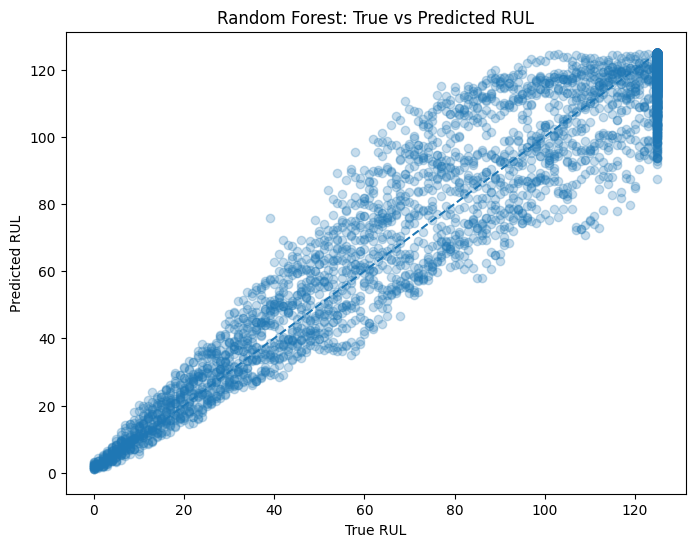

In [40]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_validation,
    random_forest_predictions,
    alpha=0.25,
)

minimum_value = min(
    y_validation.min(),
    random_forest_predictions.min(),
)

maximum_value = max(
    y_validation.max(),
    random_forest_predictions.max(),
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
)

plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("Random Forest: True vs Predicted RUL")
plt.show()

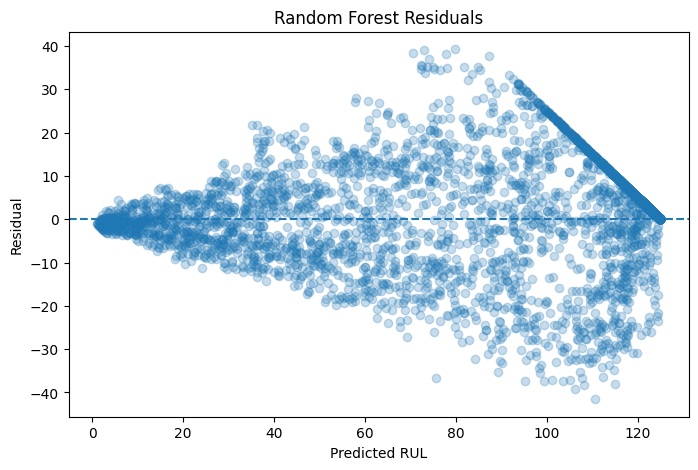

In [41]:
random_forest_residuals = (
    y_validation.to_numpy()
    - random_forest_predictions
)

plt.figure(figsize=(8, 5))

plt.scatter(
    random_forest_predictions,
    random_forest_residuals,
    alpha=0.25,
)

plt.axhline(
    y=0,
    linestyle="--",
)

plt.xlabel("Predicted RUL")
plt.ylabel("Residual")
plt.title("Random Forest Residuals")
plt.show()

In [42]:
random_forest_importance = pd.Series(
    random_forest_model.feature_importances_,
    index=feature_columns,
).sort_values(
    ascending=False
)

random_forest_importance.head(20)

s4_rolling_mean_10     0.081516
s4_ema_10              0.065817
s2_rolling_mean_10     0.065155
cycle                  0.064303
s15_rolling_mean_10    0.062361
s15_ema_10             0.060372
s11_ema_10             0.057815
s11_rolling_mean_10    0.047319
s20_rolling_mean_10    0.042265
s21_rolling_mean_10    0.041718
s21_ema_10             0.040733
s17_rolling_mean_10    0.035143
s17_ema_10             0.033952
s2_ema_10              0.032845
s3_ema_10              0.030500
s3_rolling_mean_10     0.029884
s12_expanding_mean     0.018844
s20_ema_10             0.017063
s12_rolling_mean_10    0.016032
s11_expanding_mean     0.015421
dtype: float64

### Feature Importance Note

Random Forest feature importance measures how much each feature
contributes to reducing prediction error across the decision trees.

These values are useful for exploratory interpretation, but they should
not be treated as causal importance.

Correlated features may divide or redistribute importance across
multiple related columns.

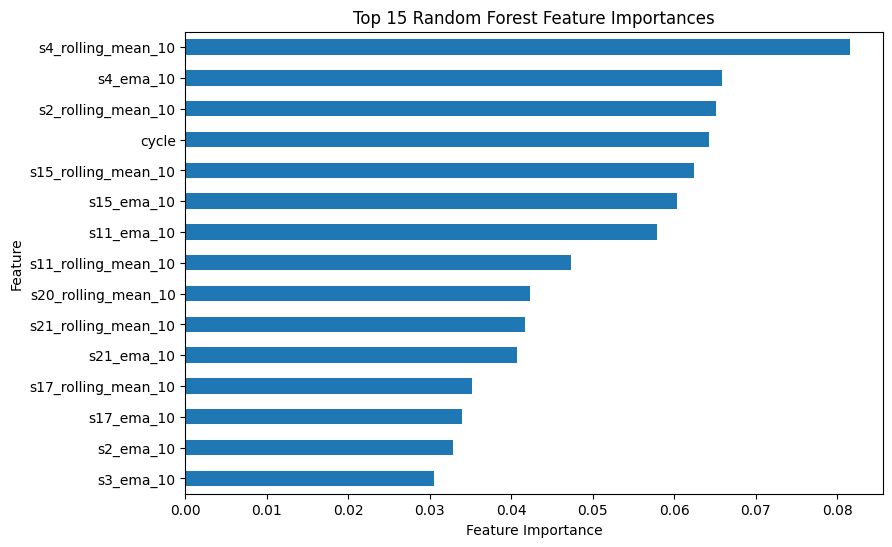

In [43]:
top_feature_importance = (
    random_forest_importance
    .head(15)
    .sort_values()
)

plt.figure(figsize=(9, 6))

top_feature_importance.plot(
    kind="barh"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")
plt.show()

## Baseline Model Comparison

The three baseline models represent increasing levels of modeling
complexity:

- Dummy Regression
- Ridge Regression
- Random Forest Regression

Their performance is compared using the same validation engines.

The objective is not only to identify the best baseline model, but also
to understand how much predictive information is captured as model
capacity increases.

In [44]:
model_comparison = (
    baseline_results
    .sort_values("MAE")
    .reset_index(drop=True)
)

model_comparison

,model,MAE,RMSE,R2
0,Random Forest,8.415468,11.574838,0.923010
1,Ridge,12.817189,16.047358,0.852018
2,Dummy Mean,36.929803,41.720825,-0.000248


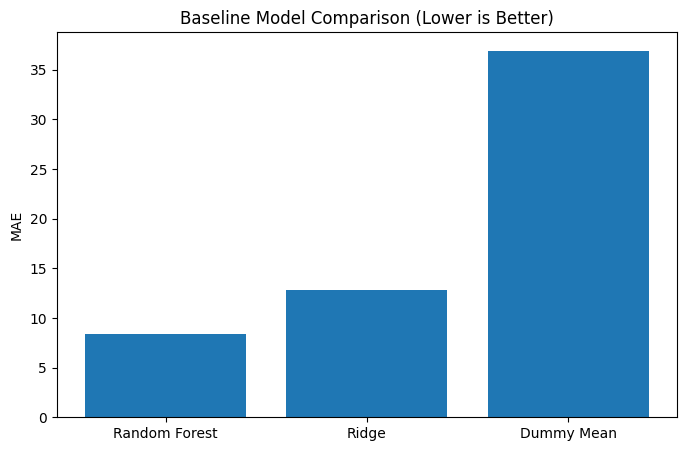

In [45]:
plt.figure(figsize=(8,5))

plt.bar(
    model_comparison["model"],
    model_comparison["MAE"],
)

plt.ylabel("MAE")
plt.title("Baseline Model Comparison (Lower is Better)")

plt.show()

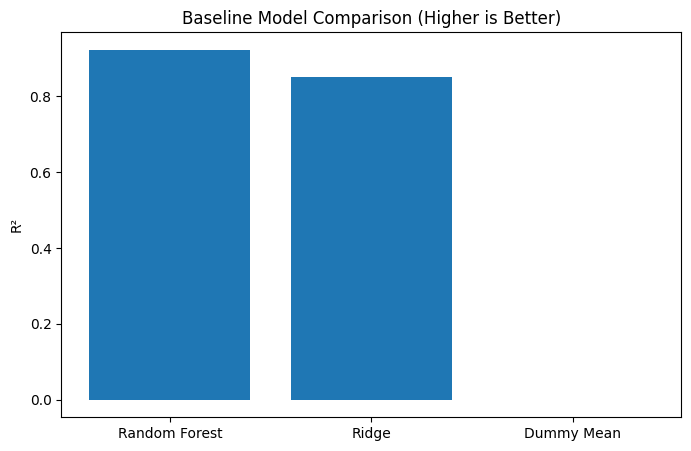

In [46]:
plt.figure(figsize=(8,5))

plt.bar(
    model_comparison["model"],
    model_comparison["R2"],
)

plt.ylabel("R²")
plt.title("Baseline Model Comparison (Higher is Better)")

plt.show()

### Random Forest Baseline Insight

Random Forest tests whether nonlinear interactions and threshold-based
relationships improve RUL prediction beyond the linear Ridge baseline.

If Random Forest substantially reduces MAE and RMSE, this indicates that
the degradation process contains meaningful nonlinear structure.

If the improvement is limited or negative, it may indicate that:

- the current feature set already represents the relationship well
  linearly,
- the model requires tuning,
- or the validation split contains engine behavior that is difficult to
  generalize.

# Notebook Summary

This notebook established predictive baselines under the finalized
project configuration:

- a capped RUL target with a maximum value of 125 cycles,
- a 10-cycle rolling window,
- a 10-cycle EMA span,
- leakage-safe historical sensor features,
- and an engine-level train-validation split.

The final validation results were:

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| Random Forest | 8.415 | 11.575 | 0.923 |
| Ridge Regression | 12.817 | 16.047 | 0.852 |
| Dummy Mean | 36.930 | 41.721 | approximately 0 |

Random Forest achieved the strongest baseline performance across all
three evaluation metrics.

The nonlinear model substantially outperformed both the constant and
regularized linear baselines, indicating that the finalized sensor
features contain meaningful nonlinear degradation information.

These capped-target metrics should not be compared directly with the
earlier linear-target metrics as if they represented the same
prediction task. The target-ablation study in Notebook 06 provides the
appropriate scientific comparison between the two target definitions.

Random Forest remains the reference baseline for comparison with the
gradient-boosting models in Notebook 05.

In [47]:
print(model_comparison)

           model        MAE       RMSE        R2
0  Random Forest   8.415468  11.574838  0.923010
1          Ridge  12.817189  16.047358  0.852018
2     Dummy Mean  36.929803  41.720825 -0.000248
